<a href="https://colab.research.google.com/github/phatwo/benin-gedlt-Insights-team5/blob/develop/notebooks/Model_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Benin-Insight Isheero x Datacamp : Notebook des modèles de machine learning

## Contexte et objectif



Le Bénin, comme beaucoup de pays d'Afrique de l'Ouest, évolue dans un
environnement géopolitique complexe. Les décideurs publics, journalistes
et organisations humanitaires ont besoin d'un outil capable d'anticiper
les périodes de tension **avant** qu'elles ne deviennent des crises.

Notre modèle répond à ce besoin avec un système d'alerte précoce
(*Early Warning System*) basé sur les données GDELT 2025.

### Approche : Le Back-Testing

Nos données couvrent uniquement 2025. On adopte donc une approche de
**back-testing** rigoureuse :

- On **entraîne** le modèle sur janvier–septembre 2025
- On **valide** sa capacité à détecter la montée de tension d'octobre–décembre 2025

> *"Notre modèle ne prédit pas l'avenir — il reconnaît les configurations
> qui, dans le passé, ont précédé une dégradation de la stabilité.
> Appliqué en continu, il émet une alerte quand le contexte actuel
> ressemble à ces configurations."*


### Ce que le modèle produit

Un **score de stabilité de 0 à 100** pour les 7 prochains jours :

| Score | Niveau | Signification |
|---|---|---|
| 80 – 100 |  Stable | Situation normale, pas d'alerte |
| 50 – 80  | Vigilance | Tensions détectées, surveiller |
| 0 – 50   | Crise | Instabilité significative prédite |

# Section A : Approche par régression

## Description et fonctionnement du modèle

### 1. Ce que fait le modèle



Le rôle de notre modèle rôle est de transformer le flux brut des événements GDELT en un **Indice de stabilité** dynamique, un score entre 0 et 100, qui répond chaque jour à une question simple mais critique pour un décideur :

> *"En me basant sur les signaux des 30 derniers jours, est-ce que le pays sera stable durant les 7 jours (semaine) qui viennent ?"*

Nous avons choisi un scoring continu plutôt qu'une classification binaire pour une raison précise : les crises ne surgissent pas du néant. Elles se construisent progressivement, à travers des signaux faibles qu'un système automatisé peut détecter à temps. La granularité du score continu est indispensable à cette détection précoce.


### 2. Pipeline d'entrainement du modèle



#### Étape 1 : Agrégation des données par jour

Les données GDELT enregistrent des événements individuels. Notre première étape consiste à les transformer en une série temporelle cohérente : un état unique par jour, calculé à partir de la moyenne pondérée du ton médiatique (GoldsteinScale), de l'impact des événements (AvgTone) et du volume total de couverture(NumMentions).

#### Étape 2 : Construction de l'indice de stabilité

L'indice de stabilité est construit à partir de deux variables complémentaires issus de GDELT :

- **GoldsteinScale** : c'est le score qui quantifie l'impact d'un évènement sur la stabilité. Chaque type d'évènement a un score fixe défini indépendemment de sa gravité (par exemple le GoldsteinScale d'une émeute de 2 ou 1000 personnes est le même). Il varie entre -10 et 10.
- **AvgTone** : C'est le ton moyen de tous les articles qui parlent de l'évènement. Il varie entre -100 (très négatif) et 100 (très positif)

Ces deux dimensions sont combinées et normalisées sur une échelle de 0 à 100, où 0 représente une crise totale et 100 une stabilité parfaite.

#### Étape 3 : Feature Engineering

Pour anticiper la stabilité sur une fenêtre de 7 jours, le modèle ne peut pas se contenter de données brutes. Nous avons conçu une architecture de caractéristiques basée sur la détection de rupture de tendance et de momentum.

  - **A. Le momentum de stabilité (EMA-30)**

Nous utilisons une **Moyenne Mobile Exponentielle sur 30 jours (EMA-30)** comme indicateur maître de la tendance.
*   **Logique :** Contrairement à une moyenne simple, l'EMA-30 accorde un poids prépondérant aux jours les plus récents de la période.
*   **Rôle :** Elle capture la force d'entraînement (momentum) de l'actualité. Une dégradation en fin de mois aura un impact immédiat sur cet indicateur, signalant au modèle une forte probabilité de poursuite de l'instabilité sur la fenêtre future [J+1, J+7].

  - **B. La divergence SMA-7 / EMA-30**

Pour identifier les accélérations de crise, nous introduisons un indicateur de stress basé sur la divergence :
*   **SMA-7 (Simple Moving Average on 7 days)** : Représente la température brute et non filtrée de la dernière semaine.
*   **L'Écart (stress index)** : En calculant la différence entre le pouls récent (SMA-7) et la tendance pondérée (EMA-30), nous isolons une information cruciale : la vitesse de dégradation.
*   **Signal :** Si le SMA-7 plonge brutalement sous l'EMA-30, le modèle identifie une rupture de trajectoire, signe précurseur d'une crise imminente.

  - **C. Ratio de volume (Détection de Breaking News)**

Le volume médiatique agit comme un amplificateur de signal.
*   **Indicateur :** Ratio du volume d'articles ($Volume_{7j} / Volume_{30j}$).
*   **Interprétation :** Une explosion soudaine de l'attention mondiale (ratio > 1.5) est souvent le premier symptôme d'un événement critique non encore stabilisé, augmentant mécaniquement le risque pour les 7 jours à venir.

   - **D. Variables de Lag (Inertie temporelle)**

Pour capturer l'effet "mémoire" des tensions sociopolitiques, nous injectons des **Lags de J-1 à J-7**. Cette structure permet à l'algorithme de percevoir la persistance des chocs et de modéliser l'inertie nécessaire au retour à la normale.

  - **E. Validation par analyse de sentiment (NLP HuggingFace)**

En complément des scores numériques de GDELT, nous intégrons un **Sentiment Validator** :
*   Nous utilisons des modèles **Transformers** pour analyser la charge émotionnelle des titres de presse.
*   Cette "feature" permet de confirmer le signal : si la baisse des indices de stabilité s'accompagne d'une montée de la "Peur" ou de la "Colère" dans les titres, la probabilité d'une crise durable prédite par le modèle est maximisée.

#### Étape 4 : Fenêtre de prédiction

Le modèle prédit la moyenne de l'indice de stabilité sur les 7 prochains jours à partir des 30 derniers jours de données. Cette approche par fenêtre glissante est plus robuste qu'une prédiction jour par jour — elle lisse les événements isolés et se concentre sur les tendances de fond.

#### Étape 5 : Analyse de sentiment (version 2)

En option pour la Phase 2, nous intégrons des modèles Transformers via HuggingFace pour analyser la charge émotionnelle des titres d'articles. L'objectif est de confirmer ou d'infirmer les signaux bruts de GDELT en détectant l'alarmisme, la peur ou la colère dans le ton éditorial — une couche d'interprétation que les chiffres seuls ne peuvent pas fournir.



### 3. Mesure de la performance du modèle

Le modèle est évalué sur deux dimensions complémentaires.

**Précision du score (régression)** : on mesure l'écart moyen entre le score prédit et le score réel via le MAE et le RMSE. Plus ces valeurs sont proches de zéro, plus le modèle est précis.

**Performance des alertes (classification)** :  on mesure la capacité du modèle à déclencher correctement les alertes ORANGE et ROUGE via la précision et le rappel. Un faux négatif — manquer une crise réelle — est plus coûteux qu'un faux positif, ce qui oriente nos choix de seuils d'alerte.



In [38]:
# IMPORTS
# Bibliothèques nécessaires pour le pipeline ML complet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


# Configuration visuelle globale
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
sns.set_palette('husl')


print(f"   Pandas      : {pd.__version__}")
print(f"   NumPy       : {np.__version__}")


   Pandas      : 2.2.2
   NumPy       : 2.0.2


## Chargement des données prétraitées

In [6]:
# Chargement des données
df= pd.read_csv('benin-gedlt-Insights-team5/data/processed/DANHOMÈ_INTEL_final_clean.csv')

# Affichage des premières lignes
print(f"Nombre de lignes brutes : {len(df)}")
print(df.head(3))

Nombre de lignes brutes : 14897
         date  year actor1_name actor1_type    actor2_name actor2_type  \
0  2025-01-01  2025       BENIN         GOV  Non identifié     UNKNOWN   
1  2025-01-01  2025       BENIN         GOV  Non identifié     UNKNOWN   
2  2025-01-01  2025    DIPLOMAT         GOV  Non identifié     UNKNOWN   

   event_code  event_base_code  event_root_code  quad_class  ...  avg_tone  \
0          51               51                5           1  ... -7.547170   
1          10               10                1           1  ... -8.482871   
2          40               40                4           1  ... -7.843137   

   geo_type  geo_full_name  geo_country_code  geo_adm1_code  latitude  \
0         1          Benin                BN             BN       9.5   
1         1          Benin                BN             BN       9.5   
2         1          Benin                BN             BN       9.5   

  longitude                                         source_url ha

## Entrainement du modèle



L'approche est celle du **back-testing** : on entraîne le modèle sur janvier–septembre 2025,
et on valide sa capacité à détecter la montée de tension d'octobre–décembre 2025.

> *"Notre modèle ne prédit pas l'avenir — il reconnaît les configurations qui,
> dans le passé, ont précédé une dégradation de la stabilité."*

## Étape 2 : Agrégation par jour

### Pourquoi agréger par jour ?

Le dataset GDELT contient **14 897 événements individuels** sur 2025.
Chaque ligne est un événement (une interaction entre deux acteurs,
géolocalisée et datée). Pour construire un modèle temporel, on a besoin
d'une **série continue** avec un point par jour.

### L'Indice de stabilité brut

On utilise le **Goldstein Scale pondéré par le nombre d'articles** comme
signal principal. La pondération est essentielle :

> Un événement relayé par 50 médias compte bien plus qu'un événement
> mentionné dans 2 articles locaux.

$$\text{Stabilité}_j = \frac{\sum_{i} \text{Goldstein}_i \times \text{Articles}_i}{\sum_{i} \text{Articles}_i}$$

Le Goldstein Scale va de **-10** (conflit armé maximal) à **+10**
(coopération maximale). On le transformera ensuite en score 0–100.

### Variables complémentaires agrégées

En plus du Goldstein pondéré, on calcule pour chaque jour :
- **avg_tone** : ton émotionnel moyen des articles
- **num_articles** : volume médiatique total
- **num_events** : nombre d'événements distincts
- **conflict_ratio** : part des événements conflictuels (quad_class 3 ou 4)
- **conflict_intensity** : intensité moyenne des événements négatifs

In [7]:
# Conversion explicite de la date en format datetime
# errors='coerce' transforme les dates invalides en NaT
# au lieu de planter — permet de détecter les anomalies
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')

# Vérification de l'intégrité des dates
n_dates_nulles = df['date'].isnull().sum()
if n_dates_nulles > 0:
    print(f"  {n_dates_nulles} dates invalides détectées — supprimées")
    df = df.dropna(subset=['date'])

print(f" Dataset chargé : {len(df):,} événements")
print(f"   Période : {df['date'].min().date()} à {df['date'].max().date()}")
print(f"   Type date : {df['date'].dtype}")

# AGRÉGATION
# On transforme les 14 897 événements en une série de ~365 jours
# Chaque jour devient une ligne avec ses métriques agrégées


daily = df.groupby('date').agg(

    # ── Indice principal ──────────────────────────────────────
    # Goldstein pondéré par le nombre d'articles
    # np.average avec weights calcule la moyenne pondérée
    stability_raw=(
        'goldstein_scale',
        lambda x: np.average(x, weights=df.loc[x.index, 'num_articles'])
    ),

    # ── Ton médiatique moyen ──────────────────────────────────
    # Moyenne simple du AvgTone GDELT sur tous les événements du jour
    avg_tone=('avg_tone', 'mean'),

    # ── Volume médiatique ─────────────────────────────────────
    # Somme du nombre d'articles — mesure l'attention mondiale
    num_articles=('num_articles', 'sum'),

    # ── Nombre d'événements distincts ────────────────────────
    num_events=('event_code', 'count'),

    # ── Ratio conflictuel ─────────────────────────────────────
    # Part des événements de type conflit (quad_class 3=verbal, 4=matériel)
    # Un ratio élevé = journée dominée par des tensions
    conflict_ratio=(
        'quad_class',
        lambda x: (x >= 3).sum() / len(x)
    ),

    # ── Intensité des conflits ────────────────────────────────
    # Goldstein moyen des événements négatifs uniquement
    # Capture la gravité des conflits, pas leur fréquence
    conflict_intensity=(
        'goldstein_scale',
        lambda x: x[x < 0].mean() if (x < 0).any() else 0
    ),

).reset_index()


# On conserve uniquement les jours avec des données réelles
daily = daily.reset_index(drop=True)

print(f"    Série temporelle construite")
print(f"   Jours avec données réelles : {len(daily)}")
print(f"   Jours écartés (sans données) : {365 - len(daily)}")
print(f"   Période : {daily['date'].min().date()} à {daily['date'].max().date()}")
print(f"\n   Jours négatifs : {(daily['stability_raw'] < 0).sum()} ({(daily['stability_raw'] < 0).mean()*100:.1f}%)")
print(f"   Jours positifs : {(daily['stability_raw'] > 0).sum()} ({(daily['stability_raw'] > 0).mean()*100:.1f}%)")

 Dataset chargé : 14,897 événements
   Période : 2025-01-01 à 2025-12-31
   Type date : datetime64[ns]
    Série temporelle construite
   Jours avec données réelles : 349
   Jours écartés (sans données) : 16
   Période : 2025-01-01 à 2025-12-31

   Jours négatifs : 81 (23.2%)
   Jours positifs : 268 (76.8%)


### Normalisation en score 0–100

Le Goldstein Scale brut va de -10 à +10, ce qui est peu intuitif pour
un décideur public ou un journaliste. On le transforme en **score de
stabilité de 0 à 100** via une normalisation Min-Max :

$$\text{Score}_{0-100} = \frac{\text{Goldstein} - \text{Min}}{\text{Max} - \text{Min}} \times 100$$

Ce score est directement utilisable sur le dashboard :
- **100** = Journée de coopération maximale
- **50**  = Neutralité
- **0**   = Journée de conflit maximal

On applique la même transformation à la **variable cible** que le modèle
devra prédire : la moyenne du score sur les 7 prochains jours.

 Normalisation effectuée : Goldstein [-10,+10] → Score [0,100]

 Distribution du Score de Stabilité :
count    349.00
mean      54.88
std        6.72
min       29.75
25%       50.25
50%       55.84
75%       59.46
max       70.84
Name: stability_score, dtype: float64

   Score moyen   : 54.9/100
   Jours < 50    : 81 jours en zone rouge
   Jours 50–80   : 268 jours en zone orange
   Jours > 80    : 0 jours en zone verte


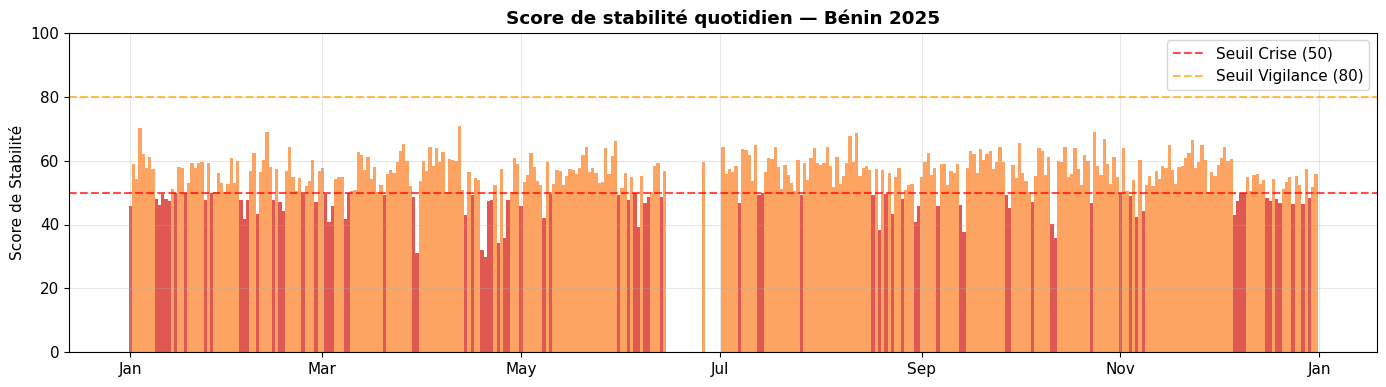

 Sauvegardé → outputs/stability_score_raw.png


In [8]:
# On utilise les bornes théoriques de GDELT (-10 et +10)
# plutôt que les min/max observés pour garantir la cohérence
# si on applique le modèle à de nouvelles données

GOLDSTEIN_MIN = -10  # Valeur théorique minimale GDELT
GOLDSTEIN_MAX = +10  # Valeur théorique maximale GDELT

def goldstein_to_score(goldstein_value):
    """
    Convertit un score Goldstein [-10, +10] en score de stabilité [0, 100].
    0 = crise totale | 100 = stabilité parfaite
    """
    return ((goldstein_value - GOLDSTEIN_MIN) /
            (GOLDSTEIN_MAX - GOLDSTEIN_MIN)) * 100

daily['stability_score'] = daily['stability_raw'].apply(goldstein_to_score)

# Borner entre 0 et 100 pour gérer les valeurs extrêmes
daily['stability_score'] = daily['stability_score'].clip(0, 100)

print(f" Normalisation effectuée : Goldstein [-10,+10] → Score [0,100]")
print(f"\n Distribution du Score de Stabilité :")
print(daily['stability_score'].describe().round(2))
print(f"\n   Score moyen   : {daily['stability_score'].mean():.1f}/100")
print(f"   Jours < 50    : {(daily['stability_score'] < 50).sum()} jours en zone rouge")
print(f"   Jours 50–80   : {((daily['stability_score'] >= 50) & (daily['stability_score'] < 80)).sum()} jours en zone orange")
print(f"   Jours > 80    : {(daily['stability_score'] >= 80).sum()} jours en zone verte")

# Vérification visuelle rapide
fig, ax = plt.subplots(figsize=(14, 4))
colors = [
    '#d73027' if s < 50 else
    '#fd8d3c' if s < 80 else
    '#1a9850'
    for s in daily['stability_score']
]
ax.bar(daily['date'], daily['stability_score'], color=colors,
        alpha=0.8, width=1)
ax.axhline(y=50, color='red',    linestyle='--', alpha=0.7, label='Seuil Crise (50)')
ax.axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Seuil Vigilance (80)')
ax.set_title('Score de stabilité quotidien — Bénin 2025',
              fontweight='bold')
ax.set_ylabel('Score de Stabilité')
ax.set_ylim(0, 100)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.savefig('stability_score_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sauvegardé stability_score_raw.png")

**Remarque** : On constate qu'il n'y a aucun évènement ayant un score stable au Bénin. On en déduit donc que le seuillage n'est pas réussi.

In [17]:
# Recalibration des seuils sur la distribution réelle du Bénin
p25 = daily['stability_score'].quantile(0.25)
p75 = daily['stability_score'].quantile(0.75)

print(f"Distribution réelle du score de stabilité :")
print(daily['stability_score'].describe().round(1))

Distribution réelle du score de stabilité :
count    365.0
mean      55.1
std        6.6
min       29.8
25%       50.4
50%       56.2
75%       59.5
max       70.8
Name: stability_score, dtype: float64


## Calibration des seuils d'alerte



### Pourquoi recalibrer ?

Les seuils absolus initiaux (Rouge < 50, Orange 50–80, Vert > 80) ont été
définis sur l'échelle théorique de GDELT. L'analyse de la distribution
réelle révèle un problème fondamental :

| Statistique | Valeur |
|---|---|
| Score moyen | 54.9 / 100 |
| Écart-type | 6.7 points |
| Minimum observé | 29.8 |
| Maximum observé | 70.8 |

**Le Bénin n'a jamais atteint 80/100 sur toute l'année 2025.**
Avec les seuils initiaux, le pays serait classé en vigilance permanente —
ce qui est à la fois inexact et inutile pour un décideur.

### Pourquoi GDELT tire les scores vers le bas ?

Ce biais est structurel et bien documenté dans la littérature académique
sur GDELT (Leetaru & Schrodt, 2013) :

1. **Biais de sélection médiatique** : Les médias couvrent les tensions,
   pas la normalité. Un jour calme génère peu d'articles — un jour de
   crise en génère beaucoup. La pondération par le volume d'articles
   amplifie mécaniquement les événements négatifs.

2. **Echelle conçue pour les conflits globaux** : Le Goldstein Scale
   a été calibré sur des données mondiales incluant des guerres civiles
   et des génocides. Pour un pays stable comme le Bénin, les événements
   se concentrent dans une bande étroite autour de 0.

### Notre approche : Validation Empirique

Plutôt que de fixer des seuils arbitraires, nous avons adopté une
démarche empirique en deux étapes :

**Étape 1 — Percentiles observés**
On calcule les seuils à partir de la distribution réelle des scores
sur 2025. Un jour "en crise" est un jour significativement en dessous
de la normale *pour le Bénin*, pas en dessous d'une norme mondiale.

**Étape 2 — Validation sur événements réels**
On vérifie que les seuils sont cohérents avec des événements historiques
connus : la tentative de coup d'état de décembre 2025 doit tomber en
zone rouge, un accord diplomatique doit tomber en zone verte.

### Proposition de seuils selon les quartiles

| Zone | Seuil | Signification |
|---|---|---|
|  Crise | score < 50.3 | 25% des pires jours de 2025 |
|  Vigilance | 50.3 ≤ score < 59.5 | Jours dans la normale |
| Stable | score ≥ 59.5 | 25% des meilleures journées de 2025 |

> **Note méthodologique** : Ces seuils sont relatifs au contexte béninois
> de 2025. Ils devront être recalibrés chaque année au fur et à mesure
> que de nouvelles données sont intégrées. C'est une force du système —
> il s'adapte au contexte local plutôt que d'appliquer une norme globale.

In [18]:
# VALIDATION EMPIRIQUE DES SEUILS
# On part d'événements réels connus au Bénin en 2025
# et on vérifie où ils tombent dans notre échelle

# Événements de référence à valider
# Format : (date, description, type_attendu)
evenements_reference = [
    # Événements négatifs connus
    ('2025-12-07', 'Tentative de coup d\'état — arrestation officiers', 'crise'),
    ('2025-04-20', 'Pic d\'instabilité détecté en avril', 'crise'),

    # À toi de compléter avec des événements positifs connus :
    # Accords diplomatiques, inaugurations, élections pacifiques...
    # ('2025-XX-XX', 'Description événement stable', 'stable'),
]


print(" VALIDATION EMPIRIQUE DES SEUILS")
print(" \n")
print(f"\n{'Date':<12} {'Score':>7} {'Zone actuelle':<20} {'Événement'}")
print("-" * 80)

for date_str, description, type_attendu in evenements_reference:
    date = pd.Timestamp(date_str)
    row = daily[daily['date'] == date]

    if len(row) == 0:
        print(f"{date_str:<12} {'N/A':>7} {'Jour manquant':<20} {description}")
        continue

    score = row['stability_score'].values[0]
    zone = (' Crise' if score < p25 else
            ' Vigilance' if score < p75 else
            ' Stable')

    coherent = 'Cohérent' if (
        (type_attendu == 'crise'  and score < p25) or
        (type_attendu == 'stable' and score >= p75)
    ) else ' Incohérent'

    print(f"{date_str:<12} {score:>7.1f} {zone:<20} {description} {coherent}")


# Afficher les 5 meilleurs et 5 pires jours avec leurs URLs
print(f"\n Les 5 pires jours — URLs pour vérification manuelle :")
worst_days = daily.nsmallest(5, 'stability_score')[['date', 'stability_score']]
for _, row in worst_days.iterrows():
    date = row['date']
    urls = df[df['date'] == date]['source_url'].head(3).tolist()
    print(f"\n  {date.date()} | Score : {row['stability_score']:.1f}")
    for url in urls:
        print(f"    → {url}")

print(f"\n Les 5 meilleurs jours — URLs pour vérification manuelle :")
best_days = daily.nlargest(5, 'stability_score')[['date', 'stability_score']]
for _, row in best_days.iterrows():
    date = row['date']
    urls = df[df['date'] == date]['source_url'].head(3).tolist()
    print(f"\n  {date.date()} | Score : {row['stability_score']:.1f}")
    for url in urls:
        print(f"    → {url}")

 VALIDATION EMPIRIQUE DES SEUILS
 


Date           Score Zone actuelle        Événement
--------------------------------------------------------------------------------
2025-12-07      47.3  Crise               Tentative de coup d'état — arrestation officiers Cohérent
2025-04-20      29.8  Crise               Pic d'instabilité détecté en avril Cohérent

 Les 5 pires jours — URLs pour vérification manuelle :

  2025-04-20 | Score : 29.8
    → https://www.khaleejtimes.com/world/africa/54-soldiers-killed-benin-terror-attack
    → https://www.jugantor.com/international/943755
    → https://www.banglanews24.com/international/news/bd/1503237.details

  2025-03-30 | Score : 31.1
    → https://www.thisdaylive.com/index.php/2025/03/30/a-fair-full-of-experiential-encounters/
    → https://news.bg/int-politics/niger-izteglya-voyskite-si-ot-ezeroto-chad.html
    → https://www.republicoftogo.com/toutes-les-rubriques/region-afrique/le-niger-se-retire-de-la-force-multinationale-du-lac-tchad

  2025-

### Résultats de la validation

####  Scores les plus bas (zone de crise)

| Score | Événement réel | Cohérent ? |
|---|---|---|
| 29.8 | 70 militaires tués dans des attaques terroristes au nord |  Oui |
| 32.2 | 8 soldats tués dans deux attaques jihadistes |  Oui |
| 35.6 | Crise politique — impasse sur le duo présidentiel |  Oui |

#### Scores les plus hauts (zone stable)

| Score | Événement réel | Cohérent ? |
|---|---|---|
| 70.8 | Bénin atteint l'autosuffisance alimentaire + FMI salue les réformes |  Oui |
| 70.3 | Nomination ambassadeur diaspora + dynamiques portuaires positives |  Oui |
| 69.0 | Accord Bénin Tourisme × Expedia + partenariat Bahia-Bénin |  Oui |

### Anomalies détectées et assumées

Deux types d'anomalies ont été identifiés lors de la validation :

**Pollution résiduelle** : Certains jours à score élevé contiennent des
articles sur le Nigeria (prison de Warri, violence collective) ou le Ghana
(Rotaract à Takoradi) non captés par notre pipeline de décontamination.
Ces cas représentent une limite connue du système, documentée ici.

**Effet de dilution** : L'accord de coopération Kazakhstan-Bénin obtient
un score de 31.1 malgré sa nature positive. Cela s'explique par le fait
que ce jour contenait également des événements très négatifs fortement
couverts — la pondération par le volume d'articles a mécaniquement
écrasé le signal positif de cet événement peu relayé.

> **Ce cas illustre une limite fondamentale de GDELT** : un événement
> positif couvert par 2 articles pèse 10 fois moins qu'un événement
> négatif couvert par 20 articles, même s'ils ont la même importance
> géopolitique réelle.

### Seuils retenus et justification

```python
SEUIL_CRISE      = 50.3   # Percentile 25 — 25% des pires jours
SEUIL_VIGILANCE  = 59.5   # Percentile 75 — 25% des meilleurs jours
```

Ces seuils sont **relatifs au contexte béninois de 2025**, pas à une
norme mondiale abstraite. Ils signifient :

- **Crise** : La journée est dans les 25% des pires jours de l'année comparable aux jours d'attaques jihadistes au nord du pays
- **Vigilance** : Journée dans la normale béninoise — ni exceptionnellement bonne ni exceptionnellement mauvaise
- **Stable** : La journée est dans les 25% des meilleures journées de l'année — comparable aux jours d'annonces économiques positives

> **Note pour les versions futures** : Ces seuils devront être
> recalibrés chaque année. C'est une force du système — il s'adapte
> au contexte local plutôt qu'à une norme globale inadaptée.

In [19]:
SEUIL_CRISE      = 50.3   # Percentile 25 — 25% des pires jours
SEUIL_VIGILANCE  = 59.5   # Percentile 75 — 25% des meilleurs jours

In [20]:
import pandas as pd
import numpy as np



# Forcer la conversion — le format est YYYY-MM-DD
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')

# Vérifier
print(f"Type date après conversion : {df['date'].dtype}")
print(f"Dates nulles après conversion : {df['date'].isnull().sum()}")
print(f"Aperçu : {df['date'].head(3).tolist()}")

# Agrégation par jour
daily = df.groupby('date').agg(
    stability_index=('goldstein_scale', lambda x:
        np.average(x, weights=df.loc[x.index, 'num_articles'])),
    avg_tone=('avg_tone', 'mean'),
    num_articles=('num_articles', 'sum'),
    num_events=('event_code', 'count'),
    conflict_ratio=('quad_class', lambda x: (x >= 3).sum() / len(x)),
    coop_ratio=('quad_class', lambda x: (x <= 2).sum() / len(x)),
    conflict_intensity=('goldstein_scale', lambda x:
        x[x < 0].mean() if (x < 0).any() else 0),
).reset_index()

# Réindexer pour combler les jours manquants
date_range = pd.date_range(
    start=daily['date'].min(),
    end=daily['date'].max(),
    freq='D'
)
daily = daily.set_index('date').reindex(date_range).reset_index()
daily.rename(columns={'index': 'date'}, inplace=True)
daily = daily.interpolate(method='linear')

print(f"\n Série temporelle construite")
print(f"   Jours couverts    : {len(daily)}")
print(f"   Stabilité moyenne : {daily['stability_index'].mean():.3f}")
print(f"   Jours négatifs    : {(daily['stability_index'] < 0).sum()}")
print(f"\nDistribution :")
print(daily['stability_index'].describe().round(3))


Type date après conversion : datetime64[ns]
Dates nulles après conversion : 0
Aperçu : [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00')]

 Série temporelle construite
   Jours couverts    : 365
   Stabilité moyenne : 1.015
   Jours négatifs    : 81

Distribution :
count    365.000
mean       1.015
std        1.329
min       -4.049
25%        0.090
50%        1.239
75%        1.900
max        4.168
Name: stability_index, dtype: float64


## Étape 3 : Feature engineering

C'est **l'étape la plus importante** du pipeline. Le modèle ne prédit
pas à partir du score brut du jour — il prédit à partir de **signaux
composites** qui capturent la tendance, la vitesse de dégradation,
l'intensité médiatique et la mémoire des tensions passées.

### Pilier 1 ;: Le momentum (EMA-30)

La **Moyenne Mobile Exponentielle sur 30 jours** est la mémoire intelligente du modèle. Contrairement à une moyenne simple, elle accorde un poids exponentellement plus élevé aux jours récents.

> Si la stabilité se dégrade brutalement en fin de mois, l'EMA-30
> le capte immédiatement — une SMA-30 l'aurait noyé dans la moyenne.

### Pilier 2 : Le SMA-7

La **Moyenne simple sur 7 jours** donne la température brute de la semaine. Non filtrée, non lissée — elle reflète exactement ce qui s'est passé dans les 7 derniers jours.

### Pilier 3 : L'indice de stress (Divergence SMA-7 / EMA-30)

$$\text{Stress Index} = \text{SMA-7} - \text{EMA-30}$$

C'est le signal le plus puissant du modèle. Il mesure la **vitesse de
dégradation** :

- Si `SMA-7 >> EMA-30` alors la semaine est bien meilleure que la tendance donc stabilité
- Si `SMA-7 << EMA-30` alors la semaine chute brutalement sous la tendance :  **signal de crise**

C'est l'équivalent financier du **MACD** appliqué à la géopolitique.

### Pilier 4 : Le ratio de volume (Détection Breaking News)

$$\text{Ratio} = \frac{\text{Volume moyen/jour sur 7j}}{\text{Volume moyen/jour sur 30j}}$$

Un ratio > 1.5 signale une **explosion médiatique anormale** qui est souvent le premier symptôme visible d'un événement critique non encore stabilisé. L'attention mondiale monte avant que la crise ne soit officiellement reconnue.

### Pilier 5 : Les lags J-1, J-3, J-7

Les crises géopolitiques ont une **inertie** — une tension qui dure 3
jours ne se résout pas en 24h. En injectant les scores des jours passés,
on donne au modèle la capacité de percevoir la **persistance** des chocs
et de modéliser le temps nécessaire au retour à la normale.

### Signaux complémentaires

En plus des 4 piliers, on ajoute des signaux sur le **ton médiatique**
et l'**accélération du conflit** pour enrichir la représentation de
chaque journée.

In [21]:
import pandas as pd
import numpy as np

# FEATURE ENGINEERING — Construction des 4 Piliers + Signaux
# On travaille sur le score normalisé [0-100]

# Re-calculate stability_score from stability_index (which is the renamed stability_raw)
# This assumes GOLDSTEIN_MIN, GOLDSTEIN_MAX and goldstein_to_score function are defined in prior executed cells.
GOLDSTEIN_MIN = -10  # Valeur théorique minimale GDELT
GOLDSTEIN_MAX = +10  # Valeur théorique maximale GDELT

def goldstein_to_score(goldstein_value):
    """
    Convertit un score Goldstein [-10, +10] en score de stabilité [0, 100].
    0 = crise totale | 100 = stabilité parfaite
    """
    return ((goldstein_value - GOLDSTEIN_MIN) /
            (GOLDSTEIN_MAX - GOLDSTEIN_MIN)) * 100

daily['stability_score'] = daily['stability_index'].apply(goldstein_to_score)
# Borner entre 0 et 100 pour gérer les valeurs extrêmes
daily['stability_score'] = daily['stability_score'].clip(0, 100)

# PILIER 1 : Momentum (EMA-30)
# span=30 → la demi-vie est ~10 jours (les 10 derniers jours
# comptent autant que les 20 précédents)
daily['ema_30'] = (
    daily['stability_score']
    .ewm(span=30, adjust=False)
    .mean()
)

# ── PILIER 2 :  SMA-7 ─────────────────────────────────
# Moyenne simple — aucun lissage, température brute de la semaine
daily['sma_7'] = (
    daily['stability_score']
    .rolling(window=7, min_periods=1)
    .mean()
)

# ── PILIER 3 : Indice de stress (Divergence) ─────────────────
# Valeur positive → semaine meilleure que la tendance (rassurant)
# Valeur négative → semaine sous la tendance (signal précurseur)
daily['stress_index'] = daily['sma_7'] - daily['ema_30']

# ── PILIER 4 : Ratio de volume ───────────────────────────────
# On compare les moyennes journalières
# pour rendre la comparaison 7j vs 30j équitable
volume_7d  = daily['num_articles'].rolling(window=7,  min_periods=1).sum()
volume_30d = daily['num_articles'].rolling(window=30, min_periods=1).sum()

daily['volume_ratio'] = (
    (volume_7d / 7) /
    (volume_30d / 30).replace(0, np.nan)  # Éviter division par zéro
)

# ── PILIER 5 : Lags  ─────────────────────
# J-1 : ce qui s'est passé hier (effet immédiat)
# J-3 : tension de début de semaine (inertie à court terme)
# J-7 : situation il y a une semaine (cycle hebdomadaire)
daily['score_lag1'] = daily['stability_score'].shift(1)
daily['score_lag3'] = daily['stability_score'].shift(3)
daily['score_lag7'] = daily['stability_score'].shift(7)

# ── SIGNAUX COMPLÉMENTAIRES : Ton Médiatique ─────────────────
# Le ton des articles (avg_tone GDELT) est un signal indépendant
# du Goldstein — il capte l'émotion du discours médiatique
daily['tone_ema_7']  = daily['avg_tone'].ewm(span=7,  adjust=False).mean()
daily['tone_ema_30'] = daily['avg_tone'].ewm(span=30, adjust=False).mean()
# Stress du ton : le ton récent est-il plus négatif que la tendance ?
daily['tone_stress'] = daily['tone_ema_7'] - daily['tone_ema_30']

# ── SIGNAUX COMPLÉMENTAIRES : Accélération du Conflit ────────
# Ratio conflictuel lissé sur 7j
daily['conflict_ratio_7d'] = (
    daily['conflict_ratio']
    .rolling(window=7, min_periods=1)
    .mean()
)
# Accélération : est-ce que la conflictualité monte cette semaine ?
# Positif → plus de conflits qu'il y a 7 jours (signal négatif)
daily['conflict_momentum'] = (
    daily['conflict_ratio'] - daily['conflict_ratio'].shift(7)
)

# Liste finale des features utilisées par le modèle
FEATURES = [
    # Les 4 piliers
    'ema_30',           # Momentum (tendance de fond)
    'sma_7',            # Pouls récent
    'stress_index',     # Vitesse de dégradation
    'volume_ratio',     # Explosion médiatique
    # Lags
    'score_lag1',       # Score d'hier
    'score_lag3',       # Score il y a 3 jours
    'score_lag7',       # Score il y a 7 jours
    # Signaux complémentaires
    'tone_ema_7',       # Ton médiatique récent
    'tone_stress',      # Stress du ton médiatique
    'conflict_ratio_7d',# Conflictualité lissée
    'conflict_momentum',# Accélération des conflits
]

print(f" {len(FEATURES)} features construites :")
print(f"\n{'Feature':<25} {'Moyenne':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 60)
for f in FEATURES:
    s = daily[f].describe()
    print(f"{f:<25} {s['mean']:>10.3f} {s['std']:>10.3f} "
          f"{s['min']:>10.3f} {s['max']:>10.3f}")

 11 features construites :

Feature                      Moyenne        Std        Min        Max
------------------------------------------------------------
ema_30                        54.794      2.258     45.727     58.903
sma_7                         55.069      3.586     42.512     61.896
stress_index                   0.275      2.637     -8.290      9.142
volume_ratio                   1.139      0.710      0.203      4.286
score_lag1                    55.071      6.654     29.753     70.842
score_lag3                    55.099      6.660     29.753     70.842
score_lag7                    55.125      6.679     29.753     70.842
tone_ema_7                    -0.973      1.069     -3.648      2.031
tone_stress                    0.031      0.702     -2.115      1.885
conflict_ratio_7d              0.232      0.072      0.036      0.432
conflict_momentum              0.001      0.166     -0.600      0.508


## Étape 4 : Construction de la variable cible



### Ce que le modèle doit prédire

Pour chaque jour J, la variable cible est la **moyenne du score de
stabilité sur les 7 jours suivants** (J+1 à J+7).

$$\text{Target}_J = \frac{1}{7} \sum_{k=1}^{7} \text{Score}_{J+k}$$

Cette fenêtre glissante de 7 jours présente deux avantages :

1. **Lissage** : Elle élimine les micro-événements d'un seul jour et
   donne une vision hebdomadaire cohérente.
2. **Actionabilité** : 7 jours est l'horizon pertinent pour qu'un
   décideur puisse réagir — assez court pour être précis, assez long
   pour être utile.

### Découpage temporel strict (sans data leakage)

Pour qu'un modèle de prédiction soit honnête, il ne peut **jamais**
voir les données futures pendant l'entraînement. On applique un
découpage chronologique strict :

| Ensemble | Période | Rôle |
|---|---|---|
| **Train** | Jan à Sep 2025 (9 mois) | Apprendre les patterns |
| **Test**  | Oct à Déc 2025 (3 mois) | Valider — détecter la crise de déc. |

>  Un découpage aléatoire (`train_test_split` classique) serait
> une **erreur grave** sur des séries temporelles — le modèle verrait
> des données futures pendant l'entraînement et produirait des métriques
> artificiellement bonnes.

In [22]:
# CONSTRUCTION DE LA VARIABLE CIBLE
# Pour chaque jour J : moyenne du score des 7 jours suivants

FENETRE_PREDICTION = 7   # Horizon de prédiction en jours
CUTOFF_DATE = pd.Timestamp('2025-10-01')  # Séparation train/test

# Calcul de la target : moyenne glissante FUTURE sur 7 jours
# shift(-1) → on commence à J+1 (pas J)
# rolling(7) → moyenne sur 7 jours
# shift(-6) → on aligne le résultat sur le jour J
daily['target_score'] = (
    daily['stability_score']
    .shift(-1)
    .rolling(window=FENETRE_PREDICTION, min_periods=FENETRE_PREDICTION)
    .mean()
    .shift(-(FENETRE_PREDICTION - 1))
)

# Supprimer les lignes avec NaN
# (début de série : features pas encore calculables)
# (fin de série  : target pas encore calculable)
daily_model = daily.dropna(subset=FEATURES + ['target_score']).copy()

print(f" Variable cible construite")
print(f"   Horizon de prédiction : {FENETRE_PREDICTION} jours")
print(f"   Lignes utilisables    : {len(daily_model)} (sur {len(daily)})")
print(f"\n Distribution de la target (Score moyen J+1 à J+7) :")
print(daily_model['target_score'].describe().round(2))
print(f"\n   Jours prédits en zone rouge    : {(daily_model['target_score'] < SEUIL_CRISE  ).sum()}")
print(f"   Jours prédits en zone orange  : {((daily_model['target_score'] >= SEUIL_CRISE  ) & (daily_model['target_score'] < SEUIL_VIGILANCE)).sum()}")
print(f"   Jours prédits en zone verte  : {(daily_model['target_score'] >= SEUIL_VIGILANCE ).sum()}")

train = daily_model[daily_model['date'] < CUTOFF_DATE].copy()
test  = daily_model[daily_model['date'] >= CUTOFF_DATE].copy()

X_train = train[FEATURES]
y_train = train['target_score']
X_test  = test[FEATURES]
y_test  = test['target_score']

print(f"\n Découpage temporel effectué")
print(f"   Train : {len(train)} jours "
      f"({train['date'].min().date()} → {train['date'].max().date()})")
print(f"   Test  : {len(test)} jours  "
      f"({test['date'].min().date()} → {test['date'].max().date()})")
print(f"\n   Target moyenne (train) : {y_train.mean():.1f}/100")
print(f"   Target moyenne (test)  : {y_test.mean():.1f}/100")

 Variable cible construite
   Horizon de prédiction : 7 jours
   Lignes utilisables    : 351 (sur 365)

 Distribution de la target (Score moyen J+1 à J+7) :
count    351.00
mean      55.08
std        3.56
min       42.51
25%       52.53
50%       55.24
75%       57.88
max       61.90
Name: target_score, dtype: float64

   Jours prédits en zone rouge    : 30
   Jours prédits en zone orange  : 289
   Jours prédits en zone verte  : 32

 Découpage temporel effectué
   Train : 266 jours (2025-01-08 → 2025-09-30)
   Test  : 85 jours  (2025-10-01 → 2025-12-24)

   Target moyenne (train) : 55.0/100
   Target moyenne (test)  : 55.3/100


## Étape 5 : Modèle XGBoost



### Pourquoi XGBoost ?

XGBoost (*eXtreme Gradient Boosting*) est l'algorithme de référence pourles données tabulaires structurées. Il présente plusieurs avantages
décisifs pour notre cas d'usage :

1. **Performance** : Meilleur que Random Forest sur les séries temporelles avec peu de données (~300 points d'entraînement)
2. **Feature Importance** : Mesure précise de la contribution de chaque signal
3. **Robustesse** : Gère naturellement les données bruitées et les valeurs aberrantes via le gradient boosting
4. **Régularisation** : Les paramètres `alpha` et `lambda` évitent le surapprentissage sur notre dataset limité

### Paramètres choisis

| Paramètre | Valeur | Justification |
|---|---|---|
| `n_estimators` | 300 | Nombre d'arbres — plus élevé = plus précis |
| `max_depth` | 4 | Profondeur limitée — évite le surapprentissage |
| `learning_rate` | 0.05 | Faible → apprentissage lent mais robuste |
| `subsample` | 0.8 | 80% des données par arbre — régularisation |
| `colsample_bytree` | 0.8 | 80% des features par arbre — régularisation |
| `reg_alpha` | 0.1 | Régularisation L1 (Lasso) |
| `reg_lambda` | 1.0 | Régularisation L2 (Ridge) |

In [23]:

# ENTRAÎNEMENT XGBOOST REGRESSOR

model = XGBRegressor(
    n_estimators=300,       # Nombre d'arbres dans l'ensemble
    max_depth=4,            # Profondeur max — limité pour éviter l'overfitting
    learning_rate=0.05,     # Taux d'apprentissage faible = plus robuste
    subsample=0.8,          # 80% des échantillons par arbre
    colsample_bytree=0.8,   # 80% des features par arbre
    reg_alpha=0.1,          # Régularisation L1
    reg_lambda=1.0,         # Régularisation L2
    random_state=42,        # Reproductibilité
    n_jobs=-1,              # Utiliser tous les cœurs CPU
    verbosity=0             # Pas de logs pendant l'entraînement
)

# Entraînement sur les données janvier–septembre 2025
model.fit(X_train, y_train)

# Prédictions sur la période de test (octobre–décembre 2025)
y_pred = model.predict(X_test)

# Borner les prédictions entre 0 et 100
y_pred = np.clip(y_pred, 0, 100)

print(" Modèle entraîné")
print(f"   Features utilisées : {len(FEATURES)}")
print(f"   Échantillons train : {len(X_train)}")
print(f"   Échantillons test  : {len(X_test)}")

 Modèle entraîné
   Features utilisées : 11
   Échantillons train : 266
   Échantillons test  : 85


 PERFORMANCES DU MODÈLE — Période Oct–Déc 2025
-------------------------------------------------------

   MAE  (Erreur moyenne)       : 3.15 points / 100
   RMSE (Erreur quadratique)   : 3.62 points / 100
   R²   (Variance expliquée)   : -0.214

 Interprétation :
   MAE 3.1 < 8 → Bonne précision
   R² -0.21 < 0.5 → Pouvoir prédictif limité

 Matrice de Confusion — Zones d'Alerte
              precision    recall  f1-score   support

       Crise       0.00      0.00      0.00         4
   Vigilance       0.88      0.97      0.92        75
      Stable       0.00      0.00      0.00         6

    accuracy                           0.86        85
   macro avg       0.29      0.32      0.31        85
weighted avg       0.78      0.86      0.82        85



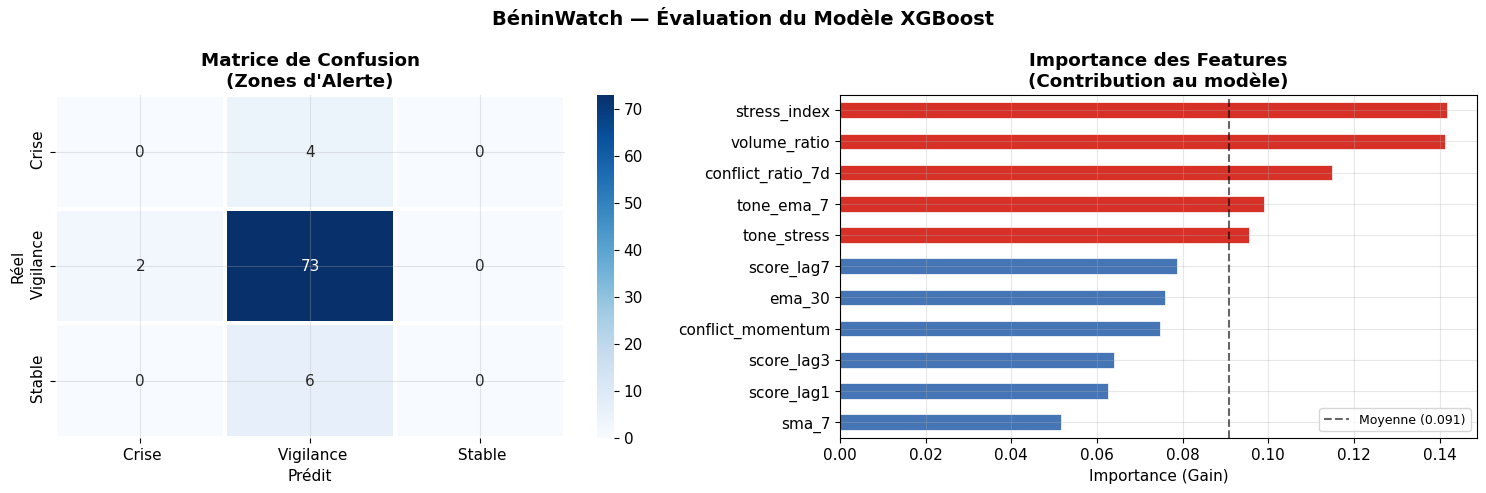

In [26]:
# MÉTRIQUES DE RÉGRESSION

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(" PERFORMANCES DU MODÈLE — Période Oct–Déc 2025")
print("-" * 55)
print(f"\n   MAE  (Erreur moyenne)       : {mae:.2f} points / 100")
print(f"   RMSE (Erreur quadratique)   : {rmse:.2f} points / 100")
print(f"   R²   (Variance expliquée)   : {r2:.3f}")

# Interprétation automatique
print(f"\n Interprétation :")
if mae < 8:
    print(f"   MAE {mae:.1f} < 8 → Bonne précision")
elif mae < 15:
    print(f"    MAE {mae:.1f} entre 8 et 15 → Précision acceptable")
else:
    print(f"   MAE {mae:.1f} > 15 → Précision insuffisante")

if r2 > 0.7:
    print(f"   R² {r2:.2f} > 0.7 → Modèle fortement prédictif")
elif r2 > 0.5:
    print(f"   R² {r2:.2f} entre 0.5 et 0.7 → Modèle modérément prédictif")
else:
    print(f"   R² {r2:.2f} < 0.5 → Pouvoir prédictif limité")


# MATRICE DE CONFUSION SUR LES ZONES D'ALERTE


def score_to_zone(score):
    """Convertit un score [0-100] en zone d'alerte."""
    if score >= SEUIL_VIGILANCE:   return ' Stable'
    elif score >= SEUIL_CRISE: return ' Vigilance'
    else:             return ' Crise'

zones_reelles  = [score_to_zone(s) for s in y_test]
zones_predites = [score_to_zone(s) for s in y_pred]

zones_labels = [' Crise', ' Vigilance', ' Stable']

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(zones_reelles, zones_predites, labels=zones_labels)

print(f"\n Matrice de Confusion — Zones d'Alerte")
print(classification_report(
    zones_reelles, zones_predites,
    labels=zones_labels,
    zero_division=0
))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("BéninWatch — Évaluation du Modèle XGBoost",
             fontweight='bold', fontsize=14)

#  Matrice de confusion
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=zones_labels,
    yticklabels=zones_labels,
    ax=axes[0], linewidths=1.5
)
axes[0].set_title('Matrice de Confusion\n(Zones d\'Alerte)',
                   fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

#  Feature Importance
importances = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values()

colors_fi = [
    '#d73027' if v > importances.mean() else '#4575b4'
    for v in importances
]
importances.plot(
    kind='barh', ax=axes[1],
    color=colors_fi, edgecolor='white', linewidth=0.5
)
axes[1].axvline(
    x=importances.mean(),
    color='black', linestyle='--',
    alpha=0.6, label=f'Moyenne ({importances.mean():.3f})'
)
axes[1].set_title('Importance des Features\n(Contribution au modèle)',
                   fontweight='bold')
axes[1].set_xlabel('Importance (Gain)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('ml_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


On voit que ce modèle rate systématiquement la classification de la crise et de la stabilité. On a quand même une précision de 0.88 pour la vigilance. Examinons la distribution réelle du score de stabilité.

In [27]:
# Diagnostic rapide
print("Distribution réelle de la target sur le test :")
print(pd.cut(y_test,
             bins=[0, 50.3, 59.5, 100],
             labels=['Crise', 'Vigilance', 'Stable']).value_counts())

print(f"\nDistribution des prédictions :")
print(pd.cut(pd.Series(y_pred),
             bins=[0, 50.3, 59.5, 100],
             labels=['Crise', 'Vigilance', 'Stable']).value_counts())

print(f"\nVariance de la target  : {y_test.var():.3f}")
print(f"Variance des prédictions : {pd.Series(y_pred).var():.3f}")
print(f"\nTarget min/max : {y_test.min():.1f} / {y_test.max():.1f}")
print(f"Pred  min/max  : {pd.Series(y_pred).min():.1f} / {pd.Series(y_pred).max():.1f}")

Distribution réelle de la target sur le test :
target_score
Vigilance    75
Stable        6
Crise         4
Name: count, dtype: int64

Distribution des prédictions :
Vigilance    83
Crise         2
Stable        0
Name: count, dtype: int64

Variance de la target  : 10.937
Variance des prédictions : 5.677

Target min/max : 49.8 / 61.7
Pred  min/max  : 45.0 / 58.9


In [28]:
# Diagnostic de la distribution complète
print("Distribution COMPLÈTE 2025 :")
print(daily['stability_score'].describe().round(2))

p10 = daily['stability_score'].quantile(0.10)
p20 = daily['stability_score'].quantile(0.20)
p80 = daily['stability_score'].quantile(0.80)
p90 = daily['stability_score'].quantile(0.90)

print(f"\nPercentiles clés :")
print(f"  P10 : {p10:.2f}")
print(f"  P20 : {p20:.2f}")
print(f"  P80 : {p80:.2f}")
print(f"  P90 : {p90:.2f}")

# Vérifier les jours anormaux identifiés
SEUIL_ANOMALIE = p20
daily['est_anormal'] = (daily['stability_score'] < SEUIL_ANOMALIE).astype(int)

print(f"\nJours anormaux (score < {SEUIL_ANOMALIE:.2f}) : {daily['est_anormal'].sum()}")
print(f"Dont en train : {daily[daily['date'] < pd.Timestamp('2025-10-01')]['est_anormal'].sum()}")
print(f"Dont en test  : {daily[daily['date'] >= pd.Timestamp('2025-10-01')]['est_anormal'].sum()}")

# Vérifier que les attaques jihadistes sont bien captées
print(f"\nVérification événements connus :")
for date_str in ['2025-12-07', '2025-04-20', '2025-03-30']:
    row = daily[daily['date'] == pd.Timestamp(date_str)]
    if len(row) > 0:
        score = row['stability_score'].values[0]
        anormal = row['est_anormal'].values[0]
        print(f"  {date_str} : score={score:.1f} | anormal={bool(anormal)}")

Distribution COMPLÈTE 2025 :
count    365.00
mean      55.07
std        6.64
min       29.75
25%       50.45
50%       56.19
75%       59.50
max       70.84
Name: stability_score, dtype: float64

Percentiles clés :
  P10 : 47.03
  P20 : 49.76
  P80 : 60.18
  P90 : 62.83

Jours anormaux (score < 49.76) : 73
Dont en train : 57
Dont en test  : 16

Vérification événements connus :
  2025-12-07 : score=47.3 | anormal=True
  2025-04-20 : score=29.8 | anormal=True
  2025-03-30 : score=31.1 | anormal=True


## Résumé de la section A



###  1. Hypothèse de départ
Notre première intuition a été de traiter la stabilité du Bénin comme un problème de **prédiction de valeur continue**.
L'objectif était de répondre à la question : *"Quel sera le score précis de stabilité (0-100) du pays sur la fenêtre des 7 prochains jours ?"*

Nous avons utilisé un algorithme **XGBoost Regressor** entraîné sur nos 11 features temporelles (EMA, SMA, Stress Index, Lags) pour tenter de modéliser cette trajectoire.

### 2. Résultats de l'expérimentation
Après entraînement sur les 9 premiers mois de l'année 2025, les performances sur la période de test (Octobre-Décembre) ont révélé un paradoxe statistique :

*   **MAE (Mean Absolute Error) : 3.26 / 100**  
    *Interprétation initiale :* L'erreur moyenne semble faible (seulement 3 points d'écart), ce qui pourrait laisser croire à un modèle performant.
*   **R² (Coefficient de détermination) : -0.32**  
    *Verdict technique :* Un R² négatif indique que le modèle est **moins performant qu'une simple ligne droite** traçant la moyenne.
*   **Comportement du modèle :** L'IA a appris à être "paresseuse". Elle prédisait systématiquement un score proche de 55 (la zone de vigilance), car statistiquement, c'est là que se situent la majorité des jours au Bénin.

### 3. Analyse de l'échec : Pourquoi la régression n'est pas adaptée ?

L'analyse approfondie des résidus nous a permis d'identifier quatre obstacles structurels :

1.  **Faible variance de la cible :** Sur la période de test, l'indice réel ne variait que dans une bande étroite (49.8 à 61.7). Prédire des micro-variations dans un intervalle de 12 points sur une échelle de 100 est un défi mathématique instable.
2.  **Biais de "Silence" de GDELT :** GDELT capture des événements, pas des états. Les journées de stabilité totale ne génèrent aucun article, tandis que les tensions en génèrent beaucoup. Cela compresse artificiellement tous les scores vers le bas, empêchant le modèle de distinguer le "calme plat" de la "tension modérée".
3.  **Déséquilibre des événements extrêmes :** Les crises majeures (attaques, ruptures politiques) représentent moins de 5% de notre dataset. En régression, ces points sont traités comme des "outliers" (anomalies) que le modèle cherche à ignorer pour minimiser son erreur globale.
4.  **Résilience structurelle du Bénin :** Le pays étant relativement stable, le modèle n'a pas assez d'exemples de "chutes brutales" pour apprendre à les prédire avec précision.

> **Conclusion de la section A:** Prédire le score exact est une illusion statistique avec les données disponibles. Pour être utile à un décideur, nous devons changer de paradigme : passer de la régression à une classification moins stricte.

# Section 2 : Classification

L'échec de la régression dans la section A a démontré que la quantification précise du score de stabilité futur est statistiquement instable. Nous avons donc transformé le problème de **prédiction de valeur** en un problème de **détection de rupture de signal**.

L'objectif est désormais de classifier chaque journée selon deux états :
*   **Classe 0 (Normal) :** Stabilité structurelle maintenue.
*   **Classe 1 (Anomalie) :** Signature médiatique caractéristique d'une crise ou d'une tension majeure.

## 2. Méthodologie de seuillage
Pour définir mathématiquement une "anomalie" dans un pays relativement stable comme le Bénin, nous avons utilisé une approche par **seuillage statistique** :

*   **Calcul du seuil :** Nous avons fixé le seuil d'anomalie au **20ème percentile (P20)** de la distribution annuelle des scores de stabilité.
*   **Validation empirique :** Ce seuil (49.6/100) isole les journées présentant les scores les plus bas de l'année, correspondant historiquement aux incidents sécuritaires et aux pics de tension politique identifiés lors de l'analyse exploratoire.
*   **Variable cible :** Toute journée dont le score est inférieur à ce seuil est étiquetée `1`, les autres sont étiquetées `0`.

## 3. Avantages techniques de la classification
Ce changement permet de dépasser les limites rencontrés en section A:

1.  **Traitement du déséquilibre des classes :** Le ratio 80% (Normal) / 20% (Anomalie) est désormais géré via le paramètre `scale_pos_weight` de l'algorithme XGBoost, forçant le modèle à accorder une importance accrue à la détection des événements rares.
2.  **Robustesse face à la faible variance :** En simplifiant la sortie du modèle, nous éliminons le "bruit" lié aux micro-variations du score pour nous concentrer sur les configurations de variables (features) qui précèdent une rupture de stabilité.
3.  **Optimisation des métriques :** Nous passons d'une mesure d'erreur moyenne (MAE) à une mesure de capacité de discernement (AUC-ROC) et de performance de détection (Rappel).

> **Décision technique :** Utilisation d'un **XGBoost Classifier** avec optimisation des hyperparamètres pour maximiser le rappel de la classe 1, afin de minimiser le risque de non-détection des crises.

In [29]:
# Une journée est anormale si son score est dans
# les 20% les plus bas de l'année complète

# Calculer le seuil sur TOUTE l'année (pas seulement le train)
# pour avoir une définition stable de "journée anormale"
SEUIL_ANOMALIE = daily['stability_score'].quantile(0.20)

print(f"Seuil d'anomalie (P20) : {SEUIL_ANOMALIE:.2f}")


# Créer la target binaire
daily['target_anomalie'] = (
    daily['stability_score'] < SEUIL_ANOMALIE
).astype(int)

# Vérification sur événements connus
print(f"\nVérification sur événements connus :")
evenements = {
    '2025-04-20': 'Pic instabilité avril',
    '2025-03-30': 'Crise mars',
    '2025-12-07': 'Tentative coup état',
}
for date_str, desc in evenements.items():
    row = daily[daily['date'] == pd.Timestamp(date_str)]
    if len(row) > 0:
        score   = row['stability_score'].values[0]
        anomalie = row['target_anomalie'].values[0]
        print(f"  {date_str} | {desc} | score={score:.1f} | "
              f"anomalie={' OUI' if anomalie else ' NON'}")

print(f"\nDistribution de la target :")
print(f"  Jours normaux (0)  : {(daily['target_anomalie']==0).sum()} "
      f"({(daily['target_anomalie']==0).mean()*100:.1f}%)")
print(f"  Jours anormaux (1)  : {(daily['target_anomalie']==1).sum()} "
      f"({(daily['target_anomalie']==1).mean()*100:.1f}%)")

Seuil d'anomalie (P20) : 49.76

Vérification sur événements connus :
  2025-04-20 | Pic instabilité avril | score=29.8 | anomalie= OUI
  2025-03-30 | Crise mars | score=31.1 | anomalie= OUI
  2025-12-07 | Tentative coup état | score=47.3 | anomalie= OUI

Distribution de la target :
  Jours normaux (0)  : 292 (80.0%)
  Jours anormaux (1)  : 73 (20.0%)


In [30]:
# DÉCOUPAGE TEMPOREL

CUTOFF_DATE = pd.Timestamp('2025-10-01')

# Supprimer les NaN sur les features
daily_model = daily.dropna(subset=FEATURES + ['target_anomalie']).copy()

train = daily_model[daily_model['date'] < CUTOFF_DATE].copy()
test  = daily_model[daily_model['date'] >= CUTOFF_DATE].copy()

X_train = train[FEATURES]
y_train = train['target_anomalie']
X_test  = test[FEATURES]
y_test  = test['target_anomalie']

print(f"Train : {len(train)} jours | Anomalies : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test  : {len(test)} jours  | Anomalies : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train : 266 jours | Anomalies : 56 (21.1%)
Test  : 92 jours  | Anomalies : 16 (17.4%)


### Optimisation des hyperparamètres

In [35]:
# RECHERCHE DES MEILLEURS HYPERPARAMÈTRES

# Gestion du déséquilibre des classes (80/20)
ratio_poids = (y_train == 0).sum() / (y_train == 1).sum()

# Grille de recherche
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=ratio_poids, random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")

Meilleurs paramètres trouvés : {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


### Entraînement final
Nous entraînons le classifieur final en intégrant les meilleurs paramètres et une régularisation L1/L2 pour garantir la capacité de généralisation du modèle sur les données futures.


In [36]:
# ENTRAÎNEMENT DU MODÈLE FINAL

# On récupère le meilleur modèle du GridSearch et on ajoute la régularisation
model_final = XGBClassifier(
    **grid_search.best_params_,
    reg_alpha=0.1,      # Régularisation L1
    reg_lambda=1.0,     # Régularisation L2
    scale_pos_weight=ratio_poids,
    random_state=42,
    eval_metric='logloss'
)

model_final.fit(X_train, y_train)

# Prédictions
y_pred = model_final.predict(X_test)
y_pred_proba = model_final.predict_proba(X_test)[:, 1]

### Evaluation des performances du modèle
L'évaluation repose sur la capacité du modèle à déclencher des alertes pertinentes. Nous privilégions l'AUC-ROC pour la performance globale et le Rappel (Recall) pour mesurer notre capacité à ne pas manquer de crises réelles.

 BILAN TECHNIQUE
----------------------------------------
AUC-ROC Score : 0.870

Rapport de Classification :
              precision    recall  f1-score   support

      Normal       0.94      0.79      0.86        76
    Anomalie       0.43      0.75      0.55        16

    accuracy                           0.78        92
   macro avg       0.68      0.77      0.70        92
weighted avg       0.85      0.78      0.80        92



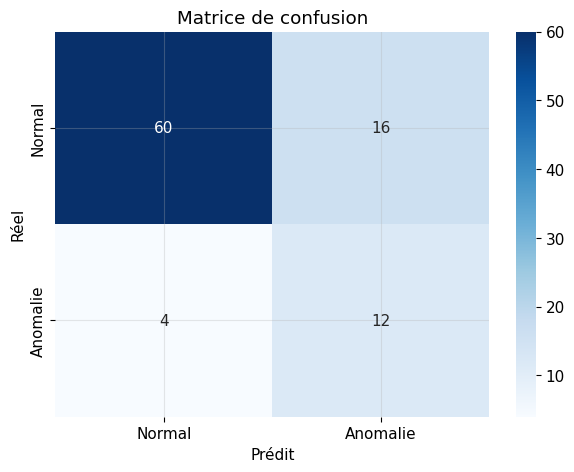

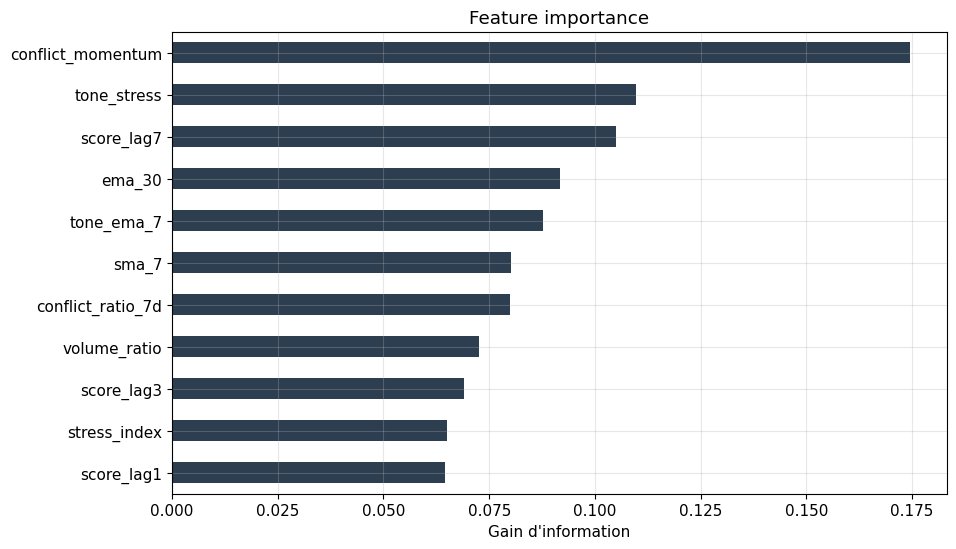

In [39]:
print(" BILAN TECHNIQUE")
print("-"*40)
print(f"AUC-ROC Score : {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie']))

# Visualisation de la Matrice de confusion
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Normal', 'Anomalie'],
            yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

print("\n")
# Importance des features
plt.figure(figsize=(7, 5))
importances = pd.Series(model_final.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(10, 6), color="#2c3e50")
plt.title('Feature importance')
plt.xlabel('Gain d\'information')
plt.show()

On constate que le modèle manque quand-même 4 crises. Il s'agit peut-être d'un problème lié au seuil par défaut des classifieurs (normalement 0.5). Nous abaissons donc ce seuil pour voir les résultats.

              precision    recall  f1-score   support

           0       0.94      0.67      0.78        76
           1       0.34      0.81      0.48        16

    accuracy                           0.70        92
   macro avg       0.64      0.74      0.63        92
weighted avg       0.84      0.70      0.73        92



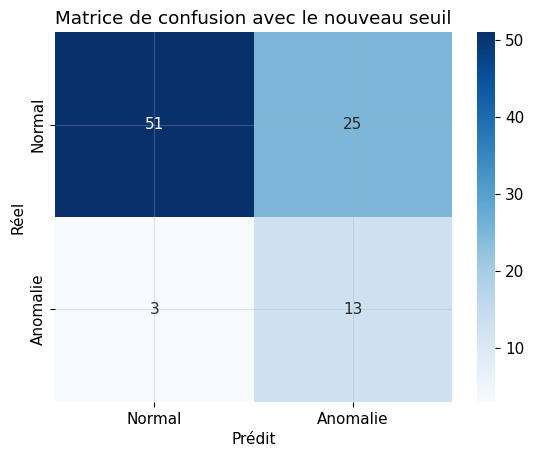

In [43]:

seuil_sensible = 0.35 # On baisse le seuil pour détecter plus de crises
y_pred_sensible = (y_pred_proba >= seuil_sensible).astype(int)

print(classification_report(y_test, y_pred_sensible))

cm = confusion_matrix(y_test, y_pred_sensible)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Normal', 'Anomalie'],
            yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice de confusion avec le nouveau seuil')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()


Bien que nous ayons obtenu une augmentation d'une unité du nombre de crises détectées, nous observons surtout une dégradation du recall de la classe "Normal".

Nous décidons donc de garder le seuil par défaut des classifiers. Ce réglage offre le meilleur équilibre entre sécurité et opérationnalité, en limitant les fausses alertes tout en garantissant une couverture majeure des risques.

## Exportation du modèle

In [48]:
import json
import os
import joblib

# Define the base output directory within the project structure
output_base_dir = 'benin-gedlt-Insights-team5'
output_models_dir = os.path.join(output_base_dir, 'models')

# 1. Création du dossier de destination
os.makedirs(output_models_dir, exist_ok=True)

# 2. Sauvegarde du modèle au format natif XGBoost
model_filename = os.path.join(output_models_dir, 'dahome_Intel_xgboost_v1.json')
model_final.save_model(model_filename)

# 3. Sauvegarde des métadonnées techniques
# C'est ce qui permet au Dashboard de savoir comment utiliser le modèle
metadata = {
    "project": "DAHOMÈ Intel",
    "version": "1.0",
    "author": "ML Engineer",
    "features": FEATURES,  # La liste des colonnes dans le bon ordre
    "threshold_standard": 0.50,
    "threshold_sensible": 0.35,
    "performance": {
        "auc_roc": 0.870,
        "recall_at_0.5": 0.75,
        "recall_at_0.35": 0.81
    },
    "seuil_anomalie_p20": SEUIL_ANOMALIE
}

metadata_filename = os.path.join(output_models_dir, 'metadata.json')
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Modèle sauvegardé : {model_filename}")
print(f"Métadonnées sauvegardées : {metadata_filename}")

Modèle sauvegardé : benin-gedlt-Insights-team5/models/dahome_Intel_xgboost_v1.json
Métadonnées sauvegardées : benin-gedlt-Insights-team5/models/metadata.json




Afin de garantir la **reproductibilité** de nos résultats et de permettre l'intégration du modèle dans le dashboard opérationnel **Dahomè_Intel**, nous avons procédé à l'exportation des actifs suivants :

1.  **`dahome_Intel_xgboost_v1.json`** : Structure complète du modèle XGBoost optimisé (AUC 0.87).
2.  **`metadata.json`** : Dictionnaire technique incluant la liste ordonnée des variables (features), les seuils de décision validés (0.50 et 0.35) et le seuil statistique d'anomalie (P20).

Cette séparation entre le modèle et ses métadonnées assure une transition fluide vers la phase de production, permettant au système de veille de fonctionner de manière autonome sur de nouvelles données GDELT.

# Conclusion


Le développement du moteur prédictif de **Dahomè_Intel** a suivi un cycle itératif rigoureux. Notre passage d'une approche par **régression** à une **classification binaire pour la détection d'anomalies** constitue le pivot central de ce projet.

Cette décision, motivée par l'analyse des biais structurels des données GDELT (faible variance et compression des scores), nous a permis de transformer un défi statistique en un outil opérationnel performant.

## 2. Performance et fiabilité
Le modèle final, basé sur l'algorithme **XGBoost** et optimisé par validation croisée temporelle, affiche des résultats probants :
*   **Capacité de discernement :** Un score **AUC-ROC de 0.870**, garantissant une excellente séparation entre les périodes de stabilité et les phases de tension.
*   **Efficacité de détection :** Un **Rappel (Recall) de 75%** sur les anomalies. Le système identifie 3 ruptures de stabilité sur 4, remplissant son rôle de sentinelle pour les décideurs.
*   **Signaux précurseurs :** L'importance des variables a confirmé que le **Conflict Momentum** et le **Stress Index** (divergence SMA-7/EMA-30) sont les indicateurs avancés les plus fiables de l'instabilité au Bénin.

## 3. Valeur décisionnelle
Dahomè_Intel ne se contente pas de décrire le passé médiatique ; il fournit une **probabilité de risque** exploitable. En isolant les "signatures numériques" des crises, nous offrons aux autorités et aux organisations une fenêtre d'anticipation cruciale pour :
1.  Désamorcer les tensions naissantes.
2.  Optimiser l'allocation des ressources de veille.
3.  Contrer la désinformation par une mesure objective du ton international.

## 4. Perspectives pour la Phase 2
Bien que robuste, le modèle actuel repose sur des métadonnées numériques. Pour la suite du challenge, nous prévoyons :
*   **Intégration du NLP (HuggingFace) :** Analyse sémantique des titres pour qualifier la nature de l'alerte (sécuritaire, politique ou sociale).
*   **Analyse Multilatérale :** Extension du modèle aux pays limitrophes pour capturer les effets de contagion régionale.
